# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 17 — Pullback Accumulation Architecture

**Research question:** once SuperbCommand identifies a `PULLBACK` inside an already-held long trend, should exposure remain unchanged or should the strategy add capital during the pullback — and, if so, how aggressively and how quickly?

Notebook 17 starts from the research architecture already accepted through Notebook 16:

- **Equity Early Reversal:** fixed 2-step 50/50 entry.
- **Other Early Reversal entries:** unchanged.
- **Profit-Taking treatment:** unchanged.
- **Long/cash only:** no short signal is inferred from `OUT`.
- **Portfolio construction:** hierarchical inverse-volatility research specification.
- **Signal hyperparameters:** frozen.
- **2026 final holdout:** locked and not accessed.

This notebook treats Pullback Accumulation as a **position-sizing / implementation** question, not as a new signal-generation question.

### Predeclared pullback architectures

| Architecture | Pullback exposure path |
|---|---|
| `PB_HOLD_100` | remain at 1.00× |
| `PB_ADD_10` | 1.10× immediately |
| `PB_ADD_25` | 1.25× immediately |
| `PB_ADD_50` | 1.50× immediately |
| `PB_2STEP_25` | 1.125× first pullback week, then 1.25× |
| `PB_5STEP_25` | add 0.05× per pullback week up to 1.25× |
| `PB_FRONTLOAD_15_10` | 1.15× first week, then 1.25× |

The purpose is **not** to pick the highest historical Sharpe mechanically. We want to know whether the response curve is broad, interpretable and robust, and whether any benefit is asset-class specific.

A candidate should only survive if the evidence is reasonably consistent across:
- asset-class aggregation;
- calendar years;
- leave-one-year-out tests;
- moving-block bootstrap;
- transaction-cost stress;
- fixed stress periods;
- portfolio-level integration.

**No 2026 data is used anywhere in this notebook.**


In [1]:
# ============================================================
# 17.1 — IMPORTS, DRIVE MOUNT, GLOBAL SETTINGS
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy"
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebook_17"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_END = pd.Timestamp("2025-12-31")
HOLDOUT_START = pd.Timestamp("2026-01-01")

WEEKS_PER_YEAR = 52.0
BASE_ONE_WAY_COST_BPS = 5.0

ASSET_CLASS_MAP = {
    "SPY": "equities",
    "EFA": "equities",
    "EEM": "equities",
    "SHY": "rates",
    "IEF": "rates",
    "TLT": "rates",
    "TIP": "rates",
    "GLD": "commodities",
    "DBC": "commodities",
    "UUP": "fx",
    "BTC-USD": "crypto",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 final holdout: LOCKED")


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 final holdout: LOCKED


## 17.2 Research controls

Notebook 17 deliberately freezes the earlier choices. It does **not** reopen oscillator construction, state definitions, Early-Reversal pacing, Profit-Taking design, asset universe or portfolio-weighting family.

The only treatment variable is **exposure during `pullback_active` weeks**.


In [2]:
# ============================================================
# 17.3 — ROBUST SIGNAL-PANEL DISCOVERY
# ============================================================

def find_first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

def recursive_find(patterns):
    hits = []
    for pat in patterns:
        hits.extend(PROJECT_ROOT.rglob(pat))
    return sorted(set(hits))

SIGNAL_PATH = find_first_existing([
    DATA_PROCESSED / "superbcommand_weekly_signal_panel.parquet",
    DATA_PROCESSED / "superbcommand_signal_panel.parquet",
])

if SIGNAL_PATH is None:
    hits = recursive_find([
        "*superbcommand*weekly*signal*panel*.parquet",
        "*superbcommand*signal*panel*.parquet",
        "*signal*panel*.parquet",
    ])
    SIGNAL_PATH = hits[0] if hits else None

if SIGNAL_PATH is None:
    raise FileNotFoundError("Could not locate the Notebook 02 SuperbCommand signal panel.")

print("Selected signal panel:")
print(SIGNAL_PATH)


Selected signal panel:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet


In [3]:
# ============================================================
# 17.4 — LOAD AND NORMALISE SIGNAL PANEL
# ============================================================

sig = pd.read_parquet(SIGNAL_PATH).copy()

if "ticker" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "ticker" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "ticker":
        sig = sig.reset_index()

if "date" not in sig.columns:
    if isinstance(sig.index, pd.MultiIndex) and "date" in sig.index.names:
        sig = sig.reset_index()
    elif sig.index.name == "date":
        sig = sig.reset_index()

if "ticker" not in sig.columns or "date" not in sig.columns:
    raise KeyError(
        f"Could not recover ticker/date. Columns={list(sig.columns)}; "
        f"index={sig.index.names}"
    )

sig["date"] = pd.to_datetime(sig["date"])
sig = sig[sig["date"] <= RESEARCH_END].copy()

if "asset_class" not in sig.columns:
    sig["asset_class"] = sig["ticker"].map(ASSET_CLASS_MAP)

unmapped = sorted(
    sig.loc[sig["asset_class"].isna(), "ticker"]
       .dropna().astype(str).unique().tolist()
)
if unmapped:
    raise KeyError(f"Unmapped ticker(s): {unmapped}")

required = [
    "ticker", "date", "close", "asset_class",
    "position_held",
    "early_reversal_active", "start_early_reversal",
    "pullback_active", "start_pullback",
]

missing = [c for c in required if c not in sig.columns]
if missing:
    raise KeyError(
        f"Missing required Notebook 17 fields: {missing}. "
        f"Available={list(sig.columns)}"
    )

for c in [
    "position_held", "early_reversal_active", "start_early_reversal",
    "pullback_active", "start_pullback"
]:
    sig[c] = sig[c].fillna(False).astype(bool)

sig = sig.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Signal shape:", sig.shape)
print("Max signal date:", sig["date"].max().date())
display(
    sig[["ticker","asset_class"]]
    .drop_duplicates()
    .sort_values(["asset_class","ticker"])
    .reset_index(drop=True)
)


Signal shape: (11370, 58)
Max signal date: 2025-12-26


,ticker,asset_class
0,DBC,commodities
1,GLD,commodities
2,BTC-USD,crypto
3,EEM,equities
4,EFA,equities
5,SPY,equities
6,UUP,fx
7,IEF,rates
8,SHY,rates
9,TIP,rates


In [4]:
# ============================================================
# 17.5 — RECONSTRUCT WEEKLY UNDERLYING RETURNS
# ============================================================

sig["underlying_return"] = (
    sig.groupby("ticker", observed=True)["close"]
       .pct_change()
       .replace([np.inf, -np.inf], np.nan)
)

sig["underlying_return_fwd"] = (
    sig.groupby("ticker", observed=True)["underlying_return"].shift(-1)
)

print("Forward-return observations:", sig["underlying_return_fwd"].notna().sum())


Forward-return observations: 11359


## 17.6 Freeze the Notebook 16 Early-Reversal rule

The baseline for Notebook 17 is the accepted integrated architecture:

- equities: 50% of target on the first active Early-Reversal week, then full target;
- other asset classes: unchanged.

Pullback rules are applied **after** this baseline is constructed.


In [5]:
# ============================================================
# 17.7 — EPISODE CLOCKS + FIXED EQUITY 2-STEP BASELINE
# ============================================================

def add_episode_week(df, active_col, start_col, out_col):
    out = df.copy()
    out[out_col] = np.nan

    for ticker, g in out.groupby("ticker", sort=False):
        week_counter = None

        for i in g.index:
            active = bool(out.at[i, active_col])
            start = bool(out.at[i, start_col])

            if start:
                week_counter = 0
            elif active and week_counter is not None:
                week_counter += 1
            elif not active:
                week_counter = None

            if active and week_counter is not None:
                out.at[i, out_col] = week_counter

    return out

sig2 = add_episode_week(
    sig, "early_reversal_active", "start_early_reversal", "er_week"
)
sig2 = add_episode_week(
    sig2, "pullback_active", "start_pullback", "pb_week"
)

sig2["base_exposure"] = sig2["position_held"].astype(float)

eq_er_first = (
    sig2["asset_class"].eq("equities")
    & sig2["early_reversal_active"]
    & sig2["er_week"].eq(0)
)

sig2.loc[eq_er_first, "base_exposure"] *= 0.5

print("Equity first-week ER rows:", int(eq_er_first.sum()))
print("Pullback rows:", int(sig2["pullback_active"].sum()))
print("Pullback starts:", int(sig2["start_pullback"].sum()))


Equity first-week ER rows: 21
Pullback rows: 1520
Pullback starts: 215


In [6]:
# ============================================================
# 17.8 — PREDECLARE PULLBACK ARCHITECTURES
# ============================================================

ARCHITECTURES = [
    "PB_HOLD_100",
    "PB_ADD_10",
    "PB_ADD_25",
    "PB_ADD_50",
    "PB_2STEP_25",
    "PB_5STEP_25",
    "PB_FRONTLOAD_15_10",
]

def pullback_multiplier(architecture, pb_week):
    if pd.isna(pb_week):
        return 1.0

    w = int(pb_week)

    if architecture == "PB_HOLD_100":
        return 1.00
    if architecture == "PB_ADD_10":
        return 1.10
    if architecture == "PB_ADD_25":
        return 1.25
    if architecture == "PB_ADD_50":
        return 1.50
    if architecture == "PB_2STEP_25":
        return 1.125 if w == 0 else 1.25
    if architecture == "PB_5STEP_25":
        return min(1.00 + 0.05 * (w + 1), 1.25)
    if architecture == "PB_FRONTLOAD_15_10":
        return 1.15 if w == 0 else 1.25

    raise ValueError(architecture)

display(pd.DataFrame({
    "architecture": ARCHITECTURES,
    "week_1": [pullback_multiplier(a,0) for a in ARCHITECTURES],
    "week_2": [pullback_multiplier(a,1) for a in ARCHITECTURES],
    "week_5": [pullback_multiplier(a,4) for a in ARCHITECTURES],
}))


,architecture,week_1,week_2,week_5
0,PB_HOLD_100,1.000,1.00,1.00
1,PB_ADD_10,1.100,1.10,1.10
2,PB_ADD_25,1.250,1.25,1.25
3,PB_ADD_50,1.500,1.50,1.50
4,PB_2STEP_25,1.125,1.25,1.25
5,PB_5STEP_25,1.050,1.10,1.25
6,PB_FRONTLOAD_15_10,1.150,1.25,1.25


In [7]:
# ============================================================
# 17.9 — BUILD EXPOSURES AND NET INSTRUMENT RETURNS
# ============================================================

ONE_WAY_COST = BASE_ONE_WAY_COST_BPS / 10_000.0

exposure_cols = {}
return_cols = {}

for architecture in ARCHITECTURES:
    exp = sig2["base_exposure"].copy()

    pb_mask = sig2["pullback_active"] & sig2["position_held"]

    mult = sig2.loc[pb_mask, "pb_week"].map(
        lambda w: pullback_multiplier(architecture, w)
    )

    exp.loc[pb_mask] = sig2.loc[pb_mask, "base_exposure"] * mult
    exp = exp.where(sig2["position_held"], 0.0)

    turnover = (
        exp.groupby(sig2["ticker"], observed=True)
           .diff()
           .abs()
           .fillna(exp.abs())
    )

    gross = exp * sig2["underlying_return_fwd"]
    net = gross - turnover * ONE_WAY_COST

    exposure_cols[architecture] = exp
    return_cols[architecture] = net

exposure_panel_long = sig2[
    ["ticker","date","asset_class","pb_week","pullback_active"]
].copy()

return_panel_long = sig2[["ticker","date","asset_class"]].copy()

for a in ARCHITECTURES:
    exposure_panel_long[a] = exposure_cols[a]
    return_panel_long[a] = return_cols[a]

print(
    "Exposure bounds:",
    exposure_panel_long[ARCHITECTURES].min().min(),
    exposure_panel_long[ARCHITECTURES].max().max()
)


Exposure bounds: 0.0 1.5


In [8]:
# ============================================================
# 17.10 — PERFORMANCE HELPERS
# ============================================================

def max_drawdown_from_returns(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    return float((wealth / wealth.cummax() - 1).min())

def perf_stats(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return {
            "weeks": len(r), "cagr": np.nan, "ann_vol": np.nan,
            "sharpe": np.nan, "sortino": np.nan,
            "max_drawdown": np.nan, "calmar": np.nan,
            "best_week": np.nan, "worst_week": np.nan,
            "positive_week_rate": np.nan,
        }

    n = len(r)
    total = (1 + r).prod()
    cagr = total ** (WEEKS_PER_YEAR / n) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sharpe = (
        r.mean() * WEEKS_PER_YEAR / ann_vol
        if ann_vol > 0 else np.nan
    )

    downside = r[r < 0].std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sortino = (
        r.mean() * WEEKS_PER_YEAR / downside
        if downside > 0 else np.nan
    )

    mdd = max_drawdown_from_returns(r)
    calmar = cagr / abs(mdd) if pd.notna(mdd) and mdd < 0 else np.nan

    return {
        "weeks": n,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": calmar,
        "best_week": r.max(),
        "worst_week": r.min(),
        "positive_week_rate": (r > 0).mean(),
    }


In [9]:
# ============================================================
# 17.11 — MARKET-LEVEL PERFORMANCE
# ============================================================

market_rows = []

for (ticker, asset_class), g in return_panel_long.groupby(
    ["ticker","asset_class"], observed=True
):
    for architecture in ARCHITECTURES:
        market_rows.append({
            "ticker": ticker,
            "asset_class": asset_class,
            "architecture": architecture,
            **perf_stats(g[architecture]),
        })

market_performance = pd.DataFrame(market_rows)

display(
    market_performance
    .sort_values(["ticker","sharpe"], ascending=[True,False])
    .reset_index(drop=True)
)


,ticker,asset_class,architecture,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,BTC-USD,crypto,PB_HOLD_100,588,0.616541,0.574594,1.118904,1.503536,-0.656423,0.939243,0.509658,-0.390115,0.377551
1,BTC-USD,crypto,PB_ADD_10,588,0.616660,0.585649,1.108932,1.485047,-0.680569,0.906095,0.509658,-0.390115,0.377551
2,BTC-USD,crypto,PB_5STEP_25,588,0.614768,0.597657,1.096489,1.463489,-0.695493,0.883931,0.509658,-0.390115,0.377551
3,BTC-USD,crypto,PB_2STEP_25,588,0.614453,0.601607,1.093103,1.453777,-0.708036,0.867828,0.509658,-0.390115,0.377551
4,BTC-USD,crypto,PB_FRONTLOAD_15_10,588,0.614566,0.602023,1.092887,1.453146,-0.709436,0.866274,0.509658,-0.390115,0.377551
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,UUP,fx,PB_ADD_25,982,0.005130,0.063661,0.112174,0.143693,-0.222971,0.023009,0.054573,-0.045823,0.344196
73,UUP,fx,PB_5STEP_25,982,0.005034,0.063094,0.111093,0.142135,-0.222200,0.022655,0.054573,-0.045723,0.344196
74,UUP,fx,PB_FRONTLOAD_15_10,982,0.004889,0.063530,0.108489,0.138818,-0.223035,0.021919,0.054573,-0.045773,0.344196
75,UUP,fx,PB_2STEP_25,982,0.004828,0.063499,0.107563,0.137593,-0.223051,0.021646,0.054573,-0.045760,0.344196


In [10]:
# ============================================================
# 17.12 — ASSET-CLASS AGGREGATION
# ============================================================

ac_returns = {}

for asset_class in sorted(return_panel_long["asset_class"].unique()):
    z = return_panel_long[
        return_panel_long["asset_class"] == asset_class
    ]

    for architecture in ARCHITECTURES:
        s = (
            z.pivot(index="date", columns="ticker", values=architecture)
             .mean(axis=1, skipna=True)
             .sort_index()
        )
        ac_returns[(asset_class, architecture)] = s

ac_rows = []

for (asset_class, architecture), r in ac_returns.items():
    ac_rows.append({
        "asset_class": asset_class,
        "architecture": architecture,
        **perf_stats(r),
    })

asset_class_performance = pd.DataFrame(ac_rows)

display(
    asset_class_performance
    .sort_values(["asset_class","sharpe"], ascending=[True,False])
    .reset_index(drop=True)
)


,asset_class,architecture,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,commodities,PB_ADD_50,1094,0.031424,0.134262,0.297965,0.366121,-0.443749,0.070814,0.095608,-0.108988,0.443327
1,commodities,PB_ADD_25,1094,0.030051,0.127950,0.295752,0.362467,-0.437801,0.068641,0.095608,-0.098507,0.442413
2,commodities,PB_ADD_10,1094,0.029167,0.124483,0.293557,0.358637,-0.434324,0.067155,0.095608,-0.092218,0.443327
3,commodities,PB_HOLD_100,1094,0.028553,0.122319,0.291674,0.355354,-0.432045,0.066088,0.095608,-0.092069,0.444241
4,commodities,PB_FRONTLOAD_15_10,1094,0.029396,0.127542,0.291300,0.356568,-0.436702,0.067313,0.095608,-0.098507,0.442413
5,commodities,PB_2STEP_25,1094,0.029231,0.127443,0.290175,0.355078,-0.436429,0.066979,0.095608,-0.098507,0.442413
6,commodities,PB_5STEP_25,1094,0.028695,0.126225,0.287614,0.351515,-0.432054,0.066414,0.095608,-0.098507,0.442413
7,crypto,PB_HOLD_100,588,0.616541,0.574594,1.118904,1.503536,-0.656423,0.939243,0.509658,-0.390115,0.377551
8,crypto,PB_ADD_10,588,0.616660,0.585649,1.108932,1.485047,-0.680569,0.906095,0.509658,-0.390115,0.377551
9,crypto,PB_5STEP_25,588,0.614768,0.597657,1.096489,1.463489,-0.695493,0.883931,0.509658,-0.390115,0.377551


In [11]:
# ============================================================
# 17.13 — DELTAS VS PB_HOLD_100
# ============================================================

base = (
    asset_class_performance
    .query("architecture == 'PB_HOLD_100'")
    .set_index("asset_class")
)

delta_rows = []

for _, row in asset_class_performance.iterrows():
    b = base.loc[row["asset_class"]]

    delta_rows.append({
        "asset_class": row["asset_class"],
        "architecture": row["architecture"],
        "delta_cagr_vs_hold": row["cagr"] - b["cagr"],
        "delta_sharpe_vs_hold": row["sharpe"] - b["sharpe"],
        "delta_sortino_vs_hold": row["sortino"] - b["sortino"],
        "delta_max_drawdown_vs_hold": (
            row["max_drawdown"] - b["max_drawdown"]
        ),
        "delta_calmar_vs_hold": row["calmar"] - b["calmar"],
    })

asset_class_deltas = pd.DataFrame(delta_rows)

display(
    asset_class_deltas
    .sort_values(
        ["asset_class","delta_sharpe_vs_hold"],
        ascending=[True,False]
    )
    .reset_index(drop=True)
)


,asset_class,architecture,delta_cagr_vs_hold,delta_sharpe_vs_hold,delta_sortino_vs_hold,delta_max_drawdown_vs_hold,delta_calmar_vs_hold
0,commodities,PB_ADD_50,0.002871,0.006291,0.010767,-0.011705,0.004726
1,commodities,PB_ADD_25,0.001498,0.004078,0.007113,-0.005756,0.002553
2,commodities,PB_ADD_10,0.000614,0.001883,0.003283,-0.002279,0.001068
3,commodities,PB_HOLD_100,0.000000,0.000000,0.000000,0.000000,0.000000
4,commodities,PB_FRONTLOAD_15_10,0.000843,-0.000374,0.001214,-0.004657,0.001225
5,commodities,PB_2STEP_25,0.000679,-0.001499,-0.000276,-0.004384,0.000891
6,commodities,PB_5STEP_25,0.000142,-0.004060,-0.003840,-0.000009,0.000327
7,crypto,PB_HOLD_100,0.000000,0.000000,0.000000,0.000000,0.000000
8,crypto,PB_ADD_10,0.000119,-0.009972,-0.018489,-0.024146,-0.033149
9,crypto,PB_5STEP_25,-0.001772,-0.022415,-0.040047,-0.039070,-0.055312


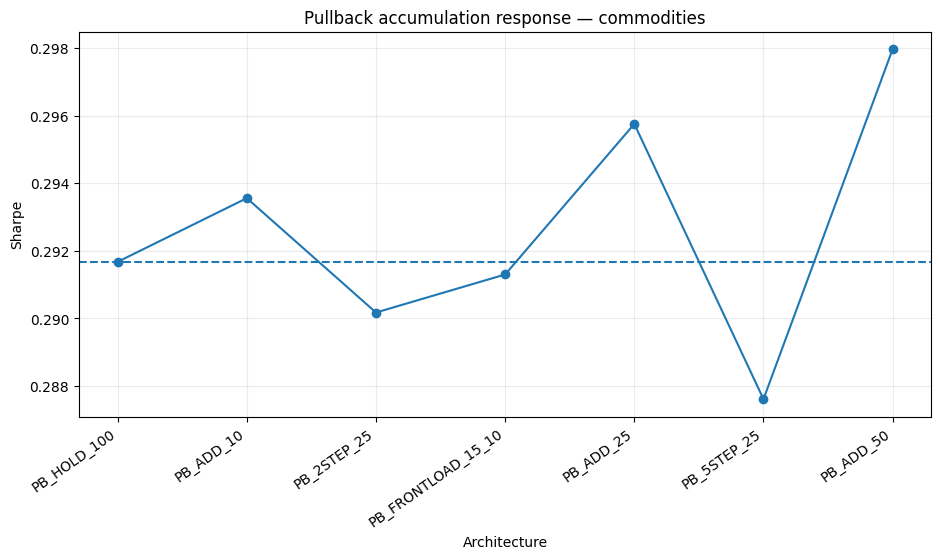

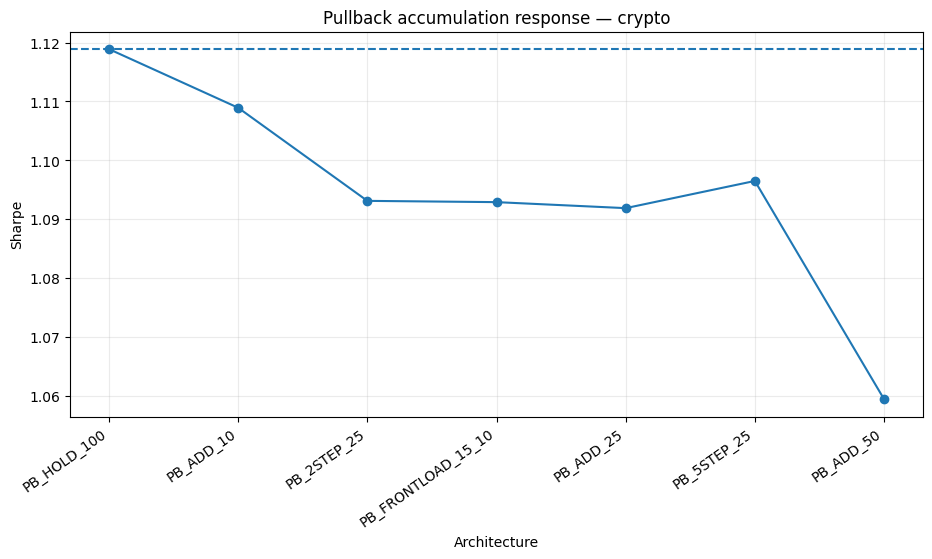

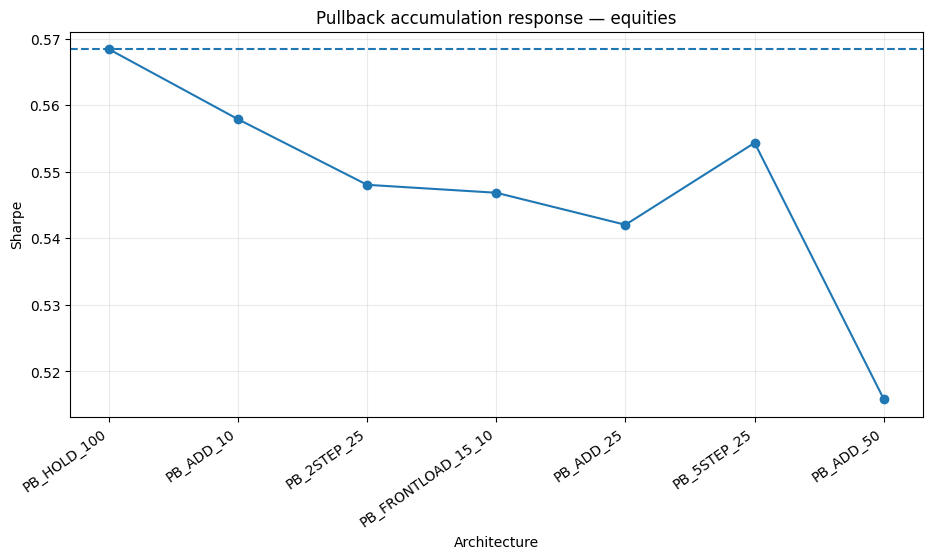

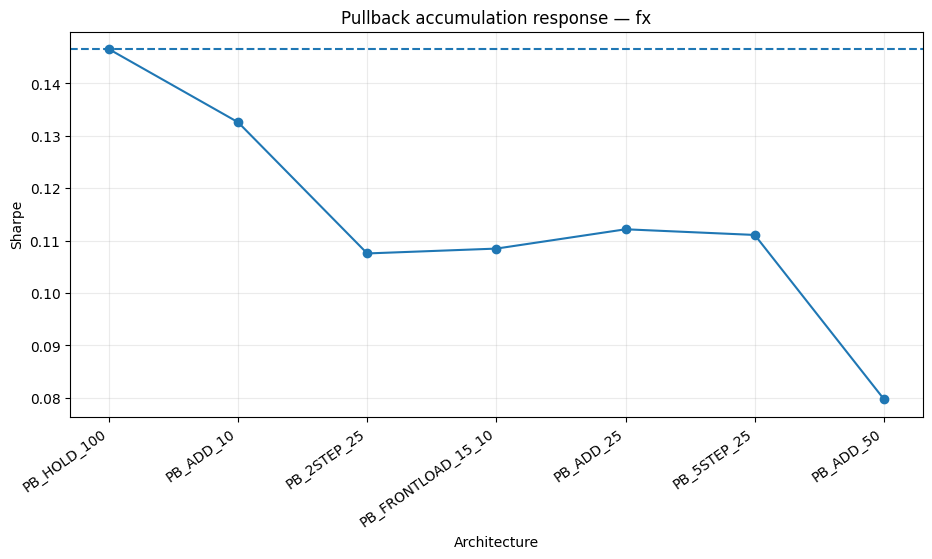

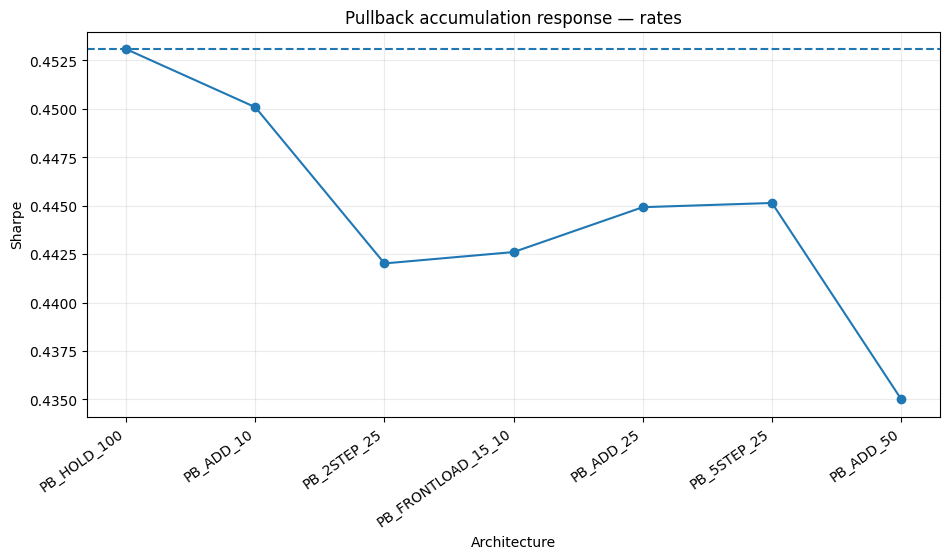

In [12]:
# ============================================================
# 17.14 — RESPONSE CURVES BY ASSET CLASS
# ============================================================

order = [
    "PB_HOLD_100",
    "PB_ADD_10",
    "PB_2STEP_25",
    "PB_FRONTLOAD_15_10",
    "PB_ADD_25",
    "PB_5STEP_25",
    "PB_ADD_50",
]

for asset_class in sorted(asset_class_performance["asset_class"].unique()):
    z = (
        asset_class_performance[
            asset_class_performance["asset_class"] == asset_class
        ]
        .set_index("architecture")
        .reindex(order)
        .dropna(subset=["sharpe"])
    )

    plt.figure(figsize=(11,5))
    plt.plot(z.index, z["sharpe"], marker="o")
    if "PB_HOLD_100" in z.index:
        plt.axhline(z.loc["PB_HOLD_100","sharpe"], linestyle="--")
    plt.title(f"Pullback accumulation response — {asset_class}")
    plt.ylabel("Sharpe")
    plt.xlabel("Architecture")
    plt.xticks(rotation=35, ha="right")
    plt.grid(alpha=0.25)
    plt.show()


## 17.15 Pullback event study

A Pullback signal occurs inside an already-held long regime. This event study measures forward underlying returns from each `start_pullback` to determine whether the signal is followed by sufficiently strong recovery to justify additional exposure.


In [13]:
# ============================================================
# 17.16 — PULLBACK EVENT STUDY
# ============================================================

HORIZONS = [1, 2, 4, 8, 13, 26]
event_rows = []

for ticker, g in sig2.groupby("ticker", observed=True):
    g = g.sort_values("date").reset_index(drop=True)

    for i in g.index[g["start_pullback"]]:
        row = {
            "ticker": ticker,
            "asset_class": g.loc[i, "asset_class"],
            "event_date": g.loc[i, "date"],
        }

        p0 = g.loc[i, "close"]

        for h in HORIZONS:
            j = i + h
            row[f"fwd_{h}w"] = (
                g.loc[j, "close"] / p0 - 1
                if j < len(g) and pd.notna(p0) and p0 != 0
                else np.nan
            )

        event_rows.append(row)

pullback_events = pd.DataFrame(event_rows)

summary_rows = []

for asset_class, g in pullback_events.groupby("asset_class", observed=True):
    for h in HORIZONS:
        x = g[f"fwd_{h}w"].dropna()
        summary_rows.append({
            "asset_class": asset_class,
            "horizon_weeks": h,
            "events": len(x),
            "mean_forward_return": x.mean(),
            "median_forward_return": x.median(),
            "positive_hit_rate": (x > 0).mean(),
        })

pullback_event_summary = pd.DataFrame(summary_rows)
display(pullback_event_summary)


,asset_class,horizon_weeks,events,mean_forward_return,median_forward_return,positive_hit_rate
0,commodities,1,42,0.006897,0.005327,0.619048
1,commodities,2,42,0.010918,0.015261,0.761905
2,commodities,4,42,0.008345,0.009302,0.619048
3,commodities,8,42,0.017725,0.007288,0.571429
4,commodities,13,42,0.019152,0.015788,0.571429
5,commodities,26,40,0.032215,0.013334,0.575000
6,crypto,1,9,0.016296,0.020664,0.555556
7,crypto,2,9,0.028716,0.070941,0.555556
8,crypto,4,9,0.015178,0.012010,0.555556
9,crypto,8,9,0.085903,0.024196,0.555556


## 17.17 Parsimonious 5-year walk-forward by asset class

For each test year from 2011–2025, each asset class selects the highest training-sample Sharpe architecture using only the previous five calendar years. This is a diagnostic of stability — not a commitment to a dynamic live selector.


In [14]:
# ============================================================
# 17.18 — 5-YEAR WALK-FORWARD BY ASSET CLASS
# ============================================================

def annualised_sharpe(r):
    r = pd.Series(r).dropna()
    v = r.std(ddof=1)
    return (
        r.mean() / v * np.sqrt(WEEKS_PER_YEAR)
        if v > 0 else np.nan
    )

wf_rows = []
wf_return_series = {}

years = list(range(2011, 2026))

for asset_class in sorted(return_panel_long["asset_class"].unique()):
    candidate_returns = {
        a: ac_returns[(asset_class, a)]
        for a in ARCHITECTURES
    }

    pieces = []

    for test_year in years:
        train_start = test_year - 5
        train_end = test_year - 1

        scores = []

        for a, r in candidate_returns.items():
            tr = r[
                (r.index.year >= train_start)
                & (r.index.year <= train_end)
            ].dropna()

            scores.append({
                "architecture": a,
                "train_sharpe": annualised_sharpe(tr),
            })

        score_df = pd.DataFrame(scores).dropna()

        if len(score_df) == 0:
            continue

        selected = (
            score_df
            .sort_values(
                ["train_sharpe","architecture"],
                ascending=[False,True]
            )
            .iloc[0]
        )

        test_r = candidate_returns[selected["architecture"]]
        test_r = test_r[test_r.index.year == test_year].dropna()

        if len(test_r) == 0:
            continue

        pieces.append(test_r)

        m = perf_stats(test_r)

        wf_rows.append({
            "asset_class": asset_class,
            "test_year": test_year,
            "train_start_year": train_start,
            "train_end_year": train_end,
            "selected_architecture": selected["architecture"],
            "selected_train_sharpe": selected["train_sharpe"],
            "test_cagr": m["cagr"],
            "test_sharpe": m["sharpe"],
            "test_max_drawdown": m["max_drawdown"],
        })

    if pieces:
        wf_return_series[asset_class] = pd.concat(pieces).sort_index()

walkforward_selection = pd.DataFrame(wf_rows)

selection_frequency = (
    walkforward_selection
    .groupby(["asset_class","selected_architecture"], observed=True)
    .size()
    .rename("years_selected")
    .reset_index()
    .sort_values(
        ["asset_class","years_selected"],
        ascending=[True,False]
    )
)

display(walkforward_selection.head(30))
display(selection_frequency)


,asset_class,test_year,train_start_year,train_end_year,selected_architecture,selected_train_sharpe,test_cagr,test_sharpe,test_max_drawdown
0,commodities,2011,2006,2010,PB_ADD_50,0.059306,0.119656,0.623457,-0.168592
1,commodities,2012,2007,2011,PB_ADD_50,0.202950,-0.086624,-0.760853,-0.161340
2,commodities,2013,2008,2012,PB_ADD_50,0.014186,-0.089816,-1.095152,-0.141363
3,commodities,2014,2009,2013,PB_ADD_50,0.408574,-0.149748,-2.035277,-0.169979
4,commodities,2015,2010,2014,PB_ADD_50,-0.002648,-0.054478,-0.738853,-0.095332
5,commodities,2016,2011,2015,PB_ADD_50,-0.398068,0.089405,0.810729,-0.103242
6,commodities,2017,2012,2016,PB_HOLD_100,-0.563668,0.090481,0.902687,-0.072626
7,commodities,2018,2013,2017,PB_HOLD_100,-0.193945,-0.091180,-1.003914,-0.133671
8,commodities,2019,2014,2018,PB_HOLD_100,-0.204231,0.132757,1.723013,-0.040685
9,commodities,2020,2015,2019,PB_HOLD_100,0.425576,-0.008352,0.046778,-0.187169


,asset_class,selected_architecture,years_selected
1,commodities,PB_ADD_50,8
2,commodities,PB_HOLD_100,6
0,commodities,PB_ADD_25,1
6,crypto,PB_HOLD_100,5
3,crypto,PB_2STEP_25,2
4,crypto,PB_ADD_10,1
5,crypto,PB_ADD_25,1
8,equities,PB_HOLD_100,12
7,equities,PB_ADD_50,3
9,fx,PB_HOLD_100,15


In [15]:
# ============================================================
# 17.19 — IN-SAMPLE DIAGNOSTIC WINNER MAP
# ============================================================

diagnostic_winners = (
    asset_class_performance
    .sort_values(
        ["asset_class","sharpe","calmar"],
        ascending=[True,False,False]
    )
    .groupby("asset_class", observed=True)
    .head(1)
    [[
        "asset_class","architecture","cagr","sharpe",
        "sortino","max_drawdown","calmar"
    ]]
    .reset_index(drop=True)
)

print("IN-SAMPLE DIAGNOSTIC ONLY — NOT A FINAL SELECTION")
display(diagnostic_winners)


IN-SAMPLE DIAGNOSTIC ONLY — NOT A FINAL SELECTION


,asset_class,architecture,cagr,sharpe,sortino,max_drawdown,calmar
0,commodities,PB_ADD_50,0.031424,0.297965,0.366121,-0.443749,0.070814
1,crypto,PB_HOLD_100,0.616541,1.118904,1.503536,-0.656423,0.939243
2,equities,PB_HOLD_100,0.071503,0.568405,0.667889,-0.319397,0.223869
3,fx,PB_HOLD_100,0.007134,0.146561,0.191133,-0.208161,0.034270
4,rates,PB_HOLD_100,0.023879,0.453085,0.595957,-0.209819,0.113810


## 17.20 Portfolio integration

The portfolio layer uses the deterministic hierarchical inverse-volatility specification already employed in the project:

- equal asset-class risk budget;
- inverse volatility within each class;
- 26-week volatility lookback;
- 13-week minimum history.

No portfolio-weighting re-optimisation occurs here.


In [16]:
# ============================================================
# 17.21 — HIERARCHICAL INVERSE-VOL WEIGHTS
# ============================================================

w = sig2[["date","ticker","asset_class","underlying_return"]].copy()
w = w.sort_values(["ticker","date"])

w["vol"] = (
    w.groupby("ticker", observed=True)["underlying_return"]
     .rolling(26, min_periods=13)
     .std()
     .reset_index(level=0, drop=True)
)

w["inv_vol"] = 1.0 / w["vol"].replace(0, np.nan)

within_den = w.groupby(
    ["date","asset_class"], observed=True
)["inv_vol"].transform("sum")

w["within_class_weight"] = w["inv_vol"] / within_den

class_validity = (
    w.groupby(["date","asset_class"], observed=True)["within_class_weight"]
     .transform(lambda x: x.notna().any())
)

active_class_count = (
    w.assign(valid_class=class_validity.astype(int))
     .groupby("date", observed=True)["asset_class"]
     .transform(lambda x: x.nunique())
)

w["asset_class_weight"] = 1.0 / active_class_count.replace(0, np.nan)
w["weight"] = w["within_class_weight"] * w["asset_class_weight"]

gross = w.groupby("date", observed=True)["weight"].transform("sum")
w["weight"] = w["weight"] / gross

weights = w[["date","ticker","asset_class","weight"]].copy()

print("Mean portfolio weight sum:",
      weights.groupby("date")["weight"].sum().mean())


Mean portfolio weight sum: 0.9881278538812786


In [17]:
# ============================================================
# 17.22 — PORTFOLIO RETURN PANEL
# ============================================================

weighted = return_panel_long.merge(
    weights,
    on=["date","ticker","asset_class"],
    how="left"
)

portfolio_returns = pd.DataFrame(
    index=pd.to_datetime(sorted(weighted["date"].dropna().unique()))
)
portfolio_returns.index.name = "date"

for a in ARCHITECTURES:
    x = (
        weighted.assign(contribution=weighted[a] * weighted["weight"])
        .groupby("date", observed=True)["contribution"]
        .sum(min_count=1)
        .sort_index()
    )
    portfolio_returns[a] = x

portfolio_returns = portfolio_returns[
    portfolio_returns.index <= RESEARCH_END
]

portfolio_rows = []

for a in ARCHITECTURES:
    portfolio_rows.append({
        "architecture": a,
        **perf_stats(portfolio_returns[a]),
    })

portfolio_performance = pd.DataFrame(portfolio_rows)

display(
    portfolio_performance.sort_values("sharpe", ascending=False)
)


,architecture,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,PB_HOLD_100,1081,0.100044,0.100515,0.999454,1.322664,-0.168970,0.592083,0.097736,-0.112597,0.506013
1,PB_ADD_10,1081,0.100796,0.102352,0.990034,1.306127,-0.178104,0.565939,0.097466,-0.114294,0.506938
5,PB_5STEP_25,1081,0.101088,0.104183,0.976976,1.290439,-0.182506,0.553888,0.097192,-0.113445,0.504163
2,PB_ADD_25,1081,0.101893,0.105327,0.974477,1.280156,-0.191742,0.531408,0.097061,-0.116839,0.505088
6,PB_FRONTLOAD_15_10,1081,0.101592,0.105016,0.974438,1.283594,-0.189032,0.537434,0.097061,-0.115142,0.505088
4,PB_2STEP_25,1081,0.101517,0.104941,0.974401,1.284386,-0.188354,0.538967,0.097061,-0.114718,0.505088
3,PB_ADD_50,1081,0.103638,0.110820,0.945835,1.230327,-0.214293,0.483625,0.096387,-0.121082,0.503238


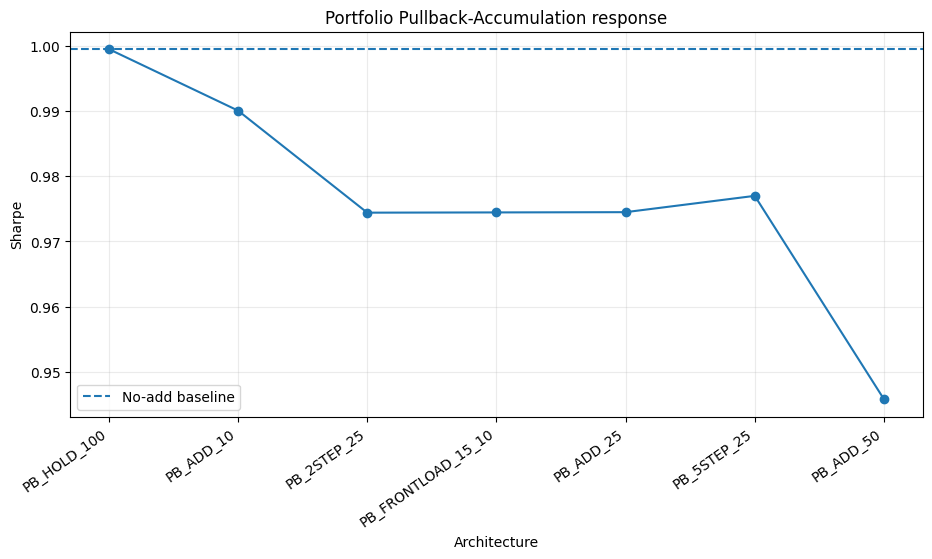

In [18]:
# ============================================================
# 17.23 — PORTFOLIO RESPONSE CURVE
# ============================================================

z = (
    portfolio_performance
    .set_index("architecture")
    .reindex(order)
    .dropna(subset=["sharpe"])
)

plt.figure(figsize=(11,5))
plt.plot(z.index, z["sharpe"], marker="o")
plt.axhline(
    z.loc["PB_HOLD_100","sharpe"],
    linestyle="--",
    label="No-add baseline"
)
plt.title("Portfolio Pullback-Accumulation response")
plt.ylabel("Sharpe")
plt.xlabel("Architecture")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [19]:
# ============================================================
# 17.24 — CALENDAR-YEAR ATTRIBUTION
# ============================================================

annual_rows = []

for a in ARCHITECTURES:
    x = portfolio_returns[["PB_HOLD_100", a]].dropna()

    for year, g in x.groupby(x.index.year):
        baseline = (1 + g["PB_HOLD_100"]).prod() - 1
        candidate = (1 + g[a]).prod() - 1

        annual_rows.append({
            "year": int(year),
            "architecture": a,
            "baseline_return": baseline,
            "candidate_return": candidate,
            "increment": candidate - baseline,
        })

annual_attribution = pd.DataFrame(annual_rows)

display(
    annual_attribution
    .query("architecture != 'PB_HOLD_100'")
    .sort_values(["architecture","year"])
)


,year,architecture,baseline_return,candidate_return,increment
84,2005,PB_2STEP_25,0.0,0.0,0.0
85,2006,PB_2STEP_25,0.0,0.0,0.0
86,2007,PB_2STEP_25,0.043977,0.04456,0.000584
87,2008,PB_2STEP_25,-0.103143,-0.104092,-0.000949
88,2009,PB_2STEP_25,0.104357,0.107394,0.003036
...,...,...,...,...,...
142,2021,PB_FRONTLOAD_15_10,0.188227,0.215807,0.027579
143,2022,PB_FRONTLOAD_15_10,0.034307,0.025526,-0.008781
144,2023,PB_FRONTLOAD_15_10,0.155245,0.157397,0.002152
145,2024,PB_FRONTLOAD_15_10,0.303638,0.317829,0.014191


In [20]:
# ============================================================
# 17.25 — LEAVE-ONE-YEAR-OUT ROBUSTNESS
# ============================================================

loo_rows = []

for a in ARCHITECTURES:
    if a == "PB_HOLD_100":
        continue

    pair = portfolio_returns[["PB_HOLD_100", a]].dropna()

    for year in sorted(pair.index.year.unique()):
        z = pair[pair.index.year != year]

        b = perf_stats(z["PB_HOLD_100"])
        c = perf_stats(z[a])

        loo_rows.append({
            "architecture": a,
            "excluded_year": int(year),
            "baseline_sharpe": b["sharpe"],
            "candidate_sharpe": c["sharpe"],
            "sharpe_gap": c["sharpe"] - b["sharpe"],
            "baseline_cagr": b["cagr"],
            "candidate_cagr": c["cagr"],
            "cagr_gap": c["cagr"] - b["cagr"],
        })

leave_one_year_out = pd.DataFrame(loo_rows)

loo_summary = (
    leave_one_year_out
    .groupby("architecture", observed=True)
    .agg(
        years=("excluded_year","count"),
        share_positive_sharpe_gap=(
            "sharpe_gap", lambda x: (x > 0).mean()
        ),
        median_sharpe_gap=("sharpe_gap","median"),
        min_sharpe_gap=("sharpe_gap","min"),
        median_cagr_gap=("cagr_gap","median"),
    )
    .sort_values("share_positive_sharpe_gap", ascending=False)
)

display(loo_summary)


,years,share_positive_sharpe_gap,median_sharpe_gap,min_sharpe_gap,median_cagr_gap
architecture,,,,,
PB_2STEP_25,21,0.0,-0.025544,-0.033417,0.001520
PB_5STEP_25,21,0.0,-0.022866,-0.029340,0.001061
PB_ADD_10,21,0.0,-0.009669,-0.012680,0.000777
PB_ADD_25,21,0.0,-0.025567,-0.032820,0.001911
PB_ADD_50,21,0.0,-0.054669,-0.068397,0.003712
PB_FRONTLOAD_15_10,21,0.0,-0.025507,-0.033277,0.001601


In [21]:
# ============================================================
# 17.26 — MOVING-BLOCK BOOTSTRAP
# ============================================================

rng = np.random.default_rng(17092026)
BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13

def sample_blocks(n, block, rng):
    starts = rng.integers(
        0, n - block + 1,
        size=int(np.ceil(n / block))
    )
    idx = np.concatenate(
        [np.arange(s, s + block) for s in starts]
    )[:n]
    return idx

boot_rows = []

for a in ARCHITECTURES:
    if a == "PB_HOLD_100":
        continue

    pair = portfolio_returns[["PB_HOLD_100", a]].dropna()
    n = len(pair)

    for i in range(BOOTSTRAP_ITERATIONS):
        idx = sample_blocks(n, BLOCK_WEEKS, rng)
        z = pair.iloc[idx].reset_index(drop=True)

        b = perf_stats(z["PB_HOLD_100"])
        c = perf_stats(z[a])

        boot_rows.append({
            "architecture": a,
            "iteration": i,
            "sharpe_gap": c["sharpe"] - b["sharpe"],
            "cagr_gap": c["cagr"] - b["cagr"],
            "sortino_gap": c["sortino"] - b["sortino"],
            "maxdd_gap": c["max_drawdown"] - b["max_drawdown"],
        })

bootstrap = pd.DataFrame(boot_rows)

bootstrap_summary = (
    bootstrap
    .groupby("architecture", observed=True)
    .agg(
        P_sharpe_gap_gt_0=("sharpe_gap", lambda x: (x > 0).mean()),
        P_cagr_gap_gt_0=("cagr_gap", lambda x: (x > 0).mean()),
        P_sortino_gap_gt_0=("sortino_gap", lambda x: (x > 0).mean()),
        P_maxdd_better=("maxdd_gap", lambda x: (x > 0).mean()),
        median_sharpe_gap=("sharpe_gap","median"),
        sharpe_gap_2_5=("sharpe_gap", lambda x: x.quantile(0.025)),
        sharpe_gap_97_5=("sharpe_gap", lambda x: x.quantile(0.975)),
        median_cagr_gap=("cagr_gap","median"),
    )
    .sort_values("P_sharpe_gap_gt_0", ascending=False)
)

display(bootstrap_summary)


,P_sharpe_gap_gt_0,P_cagr_gap_gt_0,P_sortino_gap_gt_0,P_maxdd_better,median_sharpe_gap,sharpe_gap_2_5,sharpe_gap_97_5,median_cagr_gap
architecture,,,,,,,,
PB_ADD_10,0.1246,0.8172,0.1324,0.0496,-0.008793,-0.024548,0.005796,0.000779
PB_ADD_25,0.0946,0.7992,0.1164,0.0392,-0.024208,-0.062766,0.011336,0.001791
PB_FRONTLOAD_15_10,0.0818,0.7866,0.1330,0.0426,-0.024209,-0.059427,0.009126,0.001568
PB_2STEP_25,0.0786,0.7810,0.1320,0.0378,-0.023310,-0.059475,0.009612,0.001577
PB_5STEP_25,0.0766,0.7212,0.1510,0.0676,-0.021271,-0.054295,0.008162,0.001052
PB_ADD_50,0.0766,0.7878,0.1024,0.0284,-0.051712,-0.122099,0.019848,0.003652


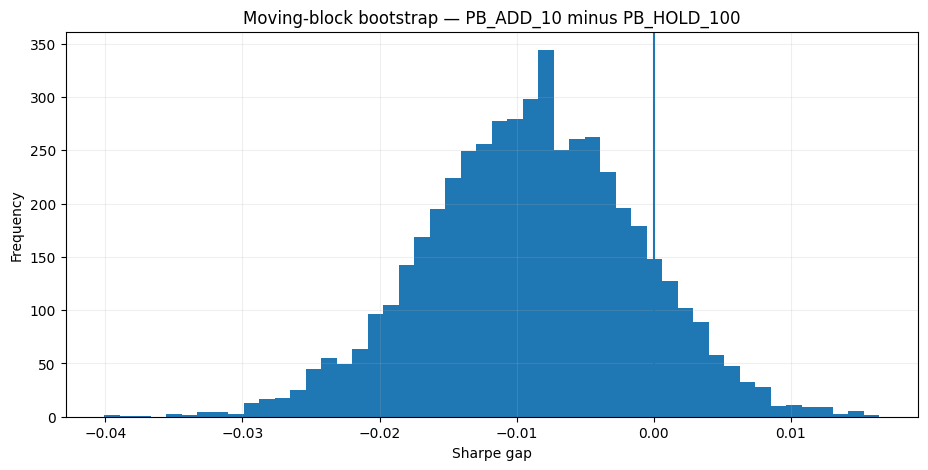

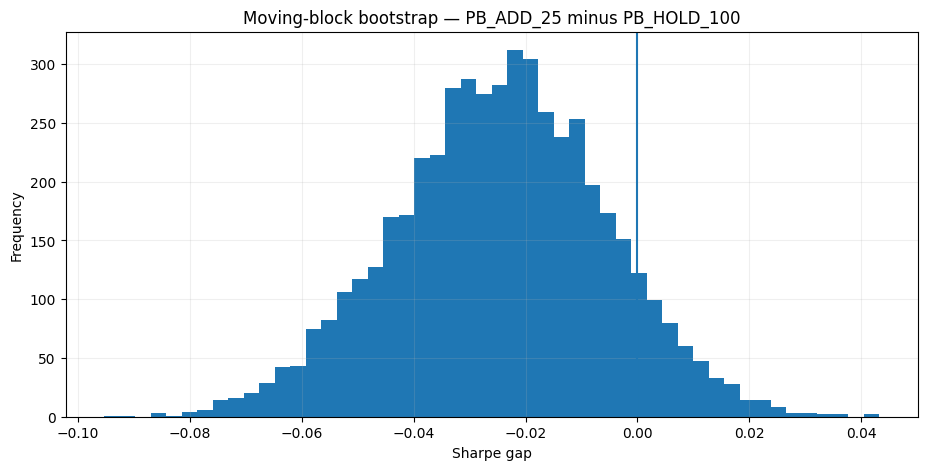

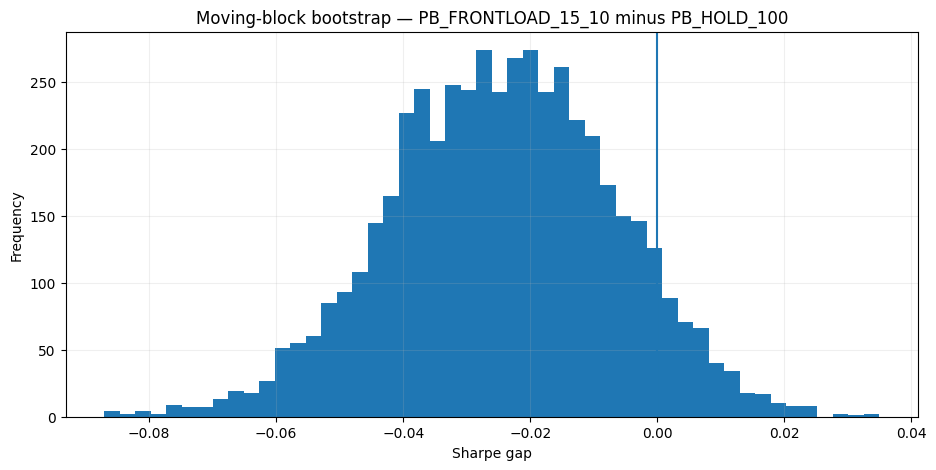

In [22]:
# ============================================================
# 17.27 — BOOTSTRAP DISTRIBUTIONS FOR TOP 3 CANDIDATES
# ============================================================

for a in bootstrap_summary.head(3).index:
    x = bootstrap.loc[
        bootstrap["architecture"] == a,
        "sharpe_gap"
    ].dropna()

    plt.figure(figsize=(11,5))
    plt.hist(x, bins=50)
    plt.axvline(0)
    plt.title(f"Moving-block bootstrap — {a} minus PB_HOLD_100")
    plt.xlabel("Sharpe gap")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.2)
    plt.show()


## 17.28 Transaction-cost stress

Pullback accumulation necessarily creates extra turnover. Any apparent advantage that disappears under modest extra cost should be treated sceptically.


In [23]:
# ============================================================
# 17.29 — TRANSACTION-COST STRESS
# ============================================================

cost_rows = []

for cost_bps in [0, 5, 10, 25]:
    one_way = cost_bps / 10_000.0
    tmp = sig2[["ticker","date","asset_class","underlying_return_fwd"]].copy()

    for a in ARCHITECTURES:
        exp = exposure_cols[a]

        turnover = (
            exp.groupby(sig2["ticker"], observed=True)
               .diff()
               .abs()
               .fillna(exp.abs())
        )

        tmp[a] = (
            exp * sig2["underlying_return_fwd"]
            - turnover * one_way
        )

    wtmp = tmp.merge(
        weights,
        on=["date","ticker","asset_class"],
        how="left"
    )

    port = {}

    for a in ARCHITECTURES:
        port[a] = (
            wtmp.assign(c=wtmp[a] * wtmp["weight"])
                .groupby("date", observed=True)["c"]
                .sum(min_count=1)
                .sort_index()
        )

    b = perf_stats(port["PB_HOLD_100"])

    for a in ARCHITECTURES:
        c = perf_stats(port[a])

        cost_rows.append({
            "cost_bps": cost_bps,
            "architecture": a,
            "cagr": c["cagr"],
            "sharpe": c["sharpe"],
            "sortino": c["sortino"],
            "max_drawdown": c["max_drawdown"],
            "sharpe_gap_vs_hold": c["sharpe"] - b["sharpe"],
            "cagr_gap_vs_hold": c["cagr"] - b["cagr"],
        })

cost_stress = pd.DataFrame(cost_rows)
display(cost_stress)


,cost_bps,architecture,cagr,sharpe,sortino,max_drawdown,sharpe_gap_vs_hold,cagr_gap_vs_hold
0,0,PB_HOLD_100,0.100358,1.002321,1.325700,-0.168814,0.000000,0.000000
1,0,PB_ADD_10,0.101216,0.993778,1.310994,-0.177903,-0.008543,0.000857
2,0,PB_ADD_25,0.102471,0.979469,1.286722,-0.191475,-0.022852,0.002112
3,0,PB_ADD_50,0.104480,0.952724,1.239412,-0.213922,-0.049598,0.004121
4,0,PB_2STEP_25,0.102090,0.979368,1.290888,-0.188087,-0.022953,0.001731
5,0,PB_5STEP_25,0.101615,0.981582,1.295863,-0.182244,-0.020739,0.001257
6,0,PB_FRONTLOAD_15_10,0.102166,0.979410,1.290109,-0.188765,-0.022911,0.001808
7,5,PB_HOLD_100,0.100044,0.999454,1.322664,-0.168970,0.000000,0.000000
8,5,PB_ADD_10,0.100796,0.990034,1.306127,-0.178104,-0.009421,0.000752
9,5,PB_ADD_25,0.101893,0.974477,1.280156,-0.191742,-0.024977,0.001849


In [24]:
# ============================================================
# 17.30 — FIXED STRESS-PERIOD COMPARISON
# ============================================================

STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for a in ARCHITECTURES:
        r = portfolio_returns[a].loc[start:end].dropna()

        if len(r) == 0:
            continue

        stress_rows.append({
            "period": period,
            "architecture": a,
            "weeks": len(r),
            "total_return": (1 + r).prod() - 1,
            "max_drawdown": max_drawdown_from_returns(r),
            "worst_week": r.min(),
        })

stress_summary = pd.DataFrame(stress_rows)
display(stress_summary)


,period,architecture,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,PB_HOLD_100,91,-0.082869,-0.118400,-0.019899
1,Global Financial Crisis,PB_ADD_10,91,-0.083167,-0.119654,-0.019912
2,Global Financial Crisis,PB_ADD_25,91,-0.083626,-0.121539,-0.019931
3,Global Financial Crisis,PB_ADD_50,91,-0.084422,-0.124687,-0.021590
4,Global Financial Crisis,PB_2STEP_25,91,-0.083363,-0.121129,-0.019931
5,Global Financial Crisis,PB_5STEP_25,91,-0.080747,-0.119197,-0.019931
6,Global Financial Crisis,PB_FRONTLOAD_15_10,91,-0.083415,-0.121211,-0.019931
7,Euro-area stress,PB_HOLD_100,65,-0.012388,-0.059964,-0.041942
8,Euro-area stress,PB_ADD_10,65,-0.014877,-0.064987,-0.042882
9,Euro-area stress,PB_ADD_25,65,-0.018619,-0.072488,-0.044291


## 17.31 Decision framework

A pullback-add rule is only compelling if it is robust after diversification and costs. If the effect is concentrated in one asset class, the next step should be a sleeve-specific integration test rather than imposing a global rule.

The parsimonious default remains `PB_HOLD_100` unless the evidence clearly supports additional exposure.


In [25]:
# ============================================================
# 17.32 — RESEARCH SCORECARD
# ============================================================

p = portfolio_performance.set_index("architecture")
base_p = p.loc["PB_HOLD_100"]

score_rows = []

for a in ARCHITECTURES:
    if a == "PB_HOLD_100":
        continue

    cand_p = p.loc[a]
    loo_s = loo_summary.loc[a]
    boot_s = bootstrap_summary.loc[a]

    c10 = cost_stress[
        (cost_stress["architecture"] == a)
        & (cost_stress["cost_bps"] == 10)
    ].iloc[0]

    score_rows.append({
        "architecture": a,
        "observed_sharpe_gap_positive":
            cand_p["sharpe"] > base_p["sharpe"],
        "observed_cagr_noninferior":
            cand_p["cagr"] >= base_p["cagr"] - 0.001,
        "loo_positive_sharpe_majority":
            loo_s["share_positive_sharpe_gap"] > 0.50,
        "bootstrap_P_sharpe_gt_0_above_50":
            boot_s["P_sharpe_gap_gt_0"] > 0.50,
        "survives_10bps":
            c10["sharpe_gap_vs_hold"] >= 0,
        "maxdd_not_materially_worse":
            cand_p["max_drawdown"] >= base_p["max_drawdown"] - 0.02,
    })

scorecard = pd.DataFrame(score_rows)
test_cols = [c for c in scorecard.columns if c != "architecture"]
scorecard["tests_passed"] = scorecard[test_cols].sum(axis=1)
scorecard["tests_total"] = len(test_cols)

display(
    scorecard.sort_values(
        ["tests_passed","architecture"],
        ascending=[False,True]
    )
)


,architecture,observed_sharpe_gap_positive,observed_cagr_noninferior,loo_positive_sharpe_majority,bootstrap_P_sharpe_gt_0_above_50,survives_10bps,maxdd_not_materially_worse,tests_passed,tests_total
3,PB_2STEP_25,False,True,False,False,False,True,2,6
4,PB_5STEP_25,False,True,False,False,False,True,2,6
0,PB_ADD_10,False,True,False,False,False,True,2,6
1,PB_ADD_25,False,True,False,False,False,False,1,6
2,PB_ADD_50,False,True,False,False,False,False,1,6
5,PB_FRONTLOAD_15_10,False,True,False,False,False,False,1,6


In [26]:
# ============================================================
# 17.33 — SAVE OUTPUTS
# ============================================================

return_panel_long.to_parquet(
    RESULTS_DIR / "17_instrument_return_panel.parquet",
    index=False
)
market_performance.to_csv(
    RESULTS_DIR / "17_market_performance.csv",
    index=False
)
asset_class_performance.to_csv(
    RESULTS_DIR / "17_asset_class_performance.csv",
    index=False
)
asset_class_deltas.to_csv(
    RESULTS_DIR / "17_asset_class_deltas_vs_hold.csv",
    index=False
)
pullback_events.to_csv(
    RESULTS_DIR / "17_pullback_events.csv",
    index=False
)
pullback_event_summary.to_csv(
    RESULTS_DIR / "17_pullback_event_summary.csv",
    index=False
)
walkforward_selection.to_csv(
    RESULTS_DIR / "17_asset_class_walkforward_selection.csv",
    index=False
)
portfolio_returns.to_parquet(
    RESULTS_DIR / "17_portfolio_return_panel.parquet"
)
portfolio_performance.to_csv(
    RESULTS_DIR / "17_portfolio_performance.csv",
    index=False
)
annual_attribution.to_csv(
    RESULTS_DIR / "17_calendar_year_attribution.csv",
    index=False
)
leave_one_year_out.to_csv(
    RESULTS_DIR / "17_leave_one_year_out.csv",
    index=False
)
bootstrap.to_parquet(
    RESULTS_DIR / "17_block_bootstrap.parquet",
    index=False
)
bootstrap_summary.to_csv(
    RESULTS_DIR / "17_block_bootstrap_summary.csv"
)
cost_stress.to_csv(
    RESULTS_DIR / "17_transaction_cost_stress.csv",
    index=False
)
stress_summary.to_csv(
    RESULTS_DIR / "17_stress_periods.csv",
    index=False
)
scorecard.to_csv(
    RESULTS_DIR / "17_scorecard.csv",
    index=False
)

print("Outputs written to:", RESULTS_DIR)


Outputs written to: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/results/notebook_17


In [27]:
# ============================================================
# 17.34 — VALIDATION SUITE
# ============================================================

checks = {
    "signal_panel_loaded": bool(len(sig2) > 0),
    "holdout_absent": bool(sig2["date"].max() <= RESEARCH_END),
    "2026_absent": bool((sig2["date"].dt.year < 2026).all()),
    "all_architectures_present": set(ARCHITECTURES).issubset(
        portfolio_returns.columns
    ),
    "pullback_events_exist": bool(sig2["start_pullback"].sum() > 0),
    "fixed_equity_2step_present": bool(eq_er_first.sum() > 0),
    "exposure_bounds_respected": bool(
        exposure_panel_long[ARCHITECTURES].min().min() >= 0
        and exposure_panel_long[ARCHITECTURES].max().max() <= 1.50
    ),
    "walkforward_training_precedes_test": bool(
        (
            walkforward_selection["train_end_year"]
            < walkforward_selection["test_year"]
        ).all()
    ) if len(walkforward_selection) else False,
    "bootstrap_5000_per_candidate": bool(
        bootstrap.groupby("architecture").size().eq(
            BOOTSTRAP_ITERATIONS
        ).all()
    ),
    "cost_stress_complete": bool(
        set(cost_stress["cost_bps"].unique()) == {0,5,10,25}
    ),
    "outputs_written": bool(
        (RESULTS_DIR / "17_portfolio_performance.csv").exists()
        and (RESULTS_DIR / "17_scorecard.csv").exists()
    ),
}

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

display(validation)

failed = [k for k,v in checks.items() if not v]

if failed:
    raise RuntimeError(
        f"Notebook 17 validation failed: {failed}"
    )

print("\n" + "="*78)
print("NOTEBOOK 17 STATUS: PASS")
print("="*78)
print("Pullback Accumulation architecture research completed.")
print("Equity Early-Reversal 2-step rule remained fixed.")
print("No signal hyperparameters were optimised.")
print("Portfolio weighting family was not re-optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Interpret the response curves and robustness evidence before changing the strategy.")


,check,passed
0,signal_panel_loaded,True
1,holdout_absent,True
2,2026_absent,True
3,all_architectures_present,True
4,pullback_events_exist,True
5,fixed_equity_2step_present,True
6,exposure_bounds_respected,True
7,walkforward_training_precedes_test,True
8,bootstrap_5000_per_candidate,True
9,cost_stress_complete,True



NOTEBOOK 17 STATUS: PASS
Pullback Accumulation architecture research completed.
Equity Early-Reversal 2-step rule remained fixed.
No signal hyperparameters were optimised.
Portfolio weighting family was not re-optimised.
2026 final holdout: NOT ACCESSED
Interpret the response curves and robustness evidence before changing the strategy.


In [28]:
# ============================================================
# 17.35 — WRITE MANIFEST
# ============================================================

manifest = {
    "notebook_id": "17",
    "notebook_name": "Pullback Accumulation Architecture",
    "project_name": "SuperbCommand - Multi-Asset CTA Strategy",
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "signal_hyperparameters_optimised": False,
    "portfolio_weighting_reoptimised": False,
    "fixed_prior_rule": {
        "asset_class": "equities",
        "signal": "Early Reversal",
        "entry": "2-step 50/50",
    },
    "research_variable": "pullback exposure architecture",
    "architectures": ARCHITECTURES,
    "base_one_way_cost_bps": BASE_ONE_WAY_COST_BPS,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "bootstrap_block_weeks": BLOCK_WEEKS,
    "outputs_dir": str(RESULTS_DIR),
    "status": "PASS" if all(checks.values()) else "FAIL",
}

manifest_path = (
    MANIFEST_DIR / "17_pullback_accumulation_architecture_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("Manifest written:", manifest_path)


Manifest written: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/17_pullback_accumulation_architecture_manifest.json


---

# End of Notebook 17

## Most useful outputs to send back

1. asset-class performance table;
2. asset-class deltas vs `PB_HOLD_100`;
3. response curves;
4. walk-forward selection frequency;
5. portfolio performance;
6. leave-one-year-out summary;
7. bootstrap summary;
8. transaction-cost stress;
9. stress-period table;
10. scorecard.

The central question is:

> **Does Pullback Accumulation contain robust incremental information that justifies increasing exposure, and is that effect global or asset-class specific?**

The 2026 final holdout remains untouched.
